In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

N_pop = 100000  # Total macro-scale population size

# --- Within-host (Micro-scale) TIVM model constants ---
T0_in = 1e7     # Initial susceptible target cells (e.g., keratinocytes)
beta_w = 1.4e-9 # Within-host infection rate constant
delta_I = 0.15  # Death rate of infected target cells
p = 4000.0      # Viral production rate per infected cell per day
c = 0.12        # Viral clearance rate constant
kappa = 0.05    # Immune-mediated viral neutralization rate
psi = 0.1       # Recruitment rate of immune effectors (M)
mu_M = 0.3      # Natural decay rate of immune effectors

# --- Pre-computation of Viral Profile (V(tau)) ---
def in_host_ode(t, y):
    T, I, V, M = y
    dT = -beta_w * T * V
    dI = beta_w * T * V - delta_I * I - kappa * I * M
    dV = p * I - c * V
    dM = psi * I - mu_M * M
    return [dT, dI, dV, dM]

t_pre = np.linspace(0, 100, 101) # 100-day window for viral kinetics
sol_vh = solve_ivp(in_host_ode, (0, 100), [T0_in, 0, 10, 0], t_eval=t_pre)
V_tau = np.maximum(sol_vh.y[2], 0)

# --- Layer 2: Dual-Route Coupling Parameters ---
beta_max_skin = 1.15 # Maximum transmission potential from cutaneous contact
beta_max_resp = 0.15 # Maximum transmission potential from respiratory droplets
EC50_L = 1e6         # Half-maximal viral load for skin-to-skin infectiousness
EC50_R = 5e5         # Half-maximal viral load for respiratory infectiousness
n_hill = 1.0         # Hill coefficient for infectiousness saturation

# --- Mapping viral loads to daily infectiousness ---
p_L, p_R = 0.9, 0.1  # Fraction of total viral load in skin (L) vs respiratory (R) compartments
V_L = V_tau * p_L
V_R = V_tau * p_R
beta_skin_tau = beta_max_skin * (V_L / (V_L + EC50_L))
beta_resp_tau = beta_max_resp * (V_R / (V_R + EC50_R))
beta_total_tau = beta_skin_tau + beta_resp_tau

# --- Macro-scale Epidemic Parameters ---
sigma = 1/7.7   # Rate of transition from Exposed to infectious (1/Incubation period)
omega = 0.5     # Rate of transition from Prodromal to symptomatic/asymptomatic
f = 0.85        # Fraction of infections that become symptomatic
gamma = 1/23.5  # Natural recovery rate from symptomatic state
gamma_A = 1/14.0# Recovery rate for asymptomatic individuals
q = 0.25        # Per-day rate of detection/quarantine for symptomatic cases
gamma_q = 1/23.5# Recovery rate for individuals in quarantine

# --- Layer 1: Behavioral Risk Stratification ---
prop_H = 0.15   # Proportion of population in the High-Risk group
prop_L = 0.85   # Proportion of population in the Low-Risk group
N_H, N_L = N_pop * prop_H, N_pop * prop_L

# Mixing Matrix Elements
c_HH, c_HL = 0.85, 0.15 # Contact probabilities for High-Risk individuals
c_LH, c_LL = 0.05, 0.05 # Contact probabilities for Low-Risk individuals

def get_vaccination_rate(t):
    # v_t: Daily fraction of susceptible population receiving effective vaccine
    return 0.015 if t > 25.0 else 0.0

In [ ]:
def unified_multiscale_model(t, y):
    # FIX: Expanded K=60 to prevent population leak (mass conservation pass)
    K = 60
    offset_L = 67 # 1(S) + 1(E) + 1(P) + 60(I) + 1(A) + 1(Q) + 1(R) + 1(Vv) = 67 per group

    def get_group_vars(arr):
        return arr[0], arr[1], arr[2], arr[3:3+K], arr[63], arr[64], arr[65], arr[66]

    S_H, E_H, P_H, I_H_list, A_H, Q_H, R_H, Vv_H = get_group_vars(y[0:67])
    S_L, E_L, P_L, I_L_list, A_L, Q_L, R_L, Vv_L = get_group_vars(y[67:])

    # Dynamic transmission mapping
    # Symptomatic: beta_total_tau[k+2] (starts at prodromal exit)
    I_eff_H = np.sum(I_H_list * beta_total_tau[2:2+K]) + (A_H * 0.5 * beta_max_skin)
    I_eff_L = np.sum(I_L_list * beta_total_tau[2:2+K]) + (A_L * 0.5 * beta_max_skin)

    lambda_H = (c_HH * I_eff_H / N_H) + (c_HL * I_eff_L / N_L)
    lambda_L = (c_LH * I_eff_H / N_H) + (c_LL * I_eff_L / N_L)

    v_t = get_vaccination_rate(t)

    def group_derivs(S, E, P, I_list, A, Q, R, Vv, lamb, N_grp):
        dS = -lamb * S - v_t * S
        dE = lamb * S - sigma * E
        dP = sigma * E - omega * P

        dI = np.zeros(K)
        dI[0] = f * omega * P - (1.0 + gamma + q) * I_list[0]
        for k in range(1, K):
            dI[k] = I_list[k-1] - (1.0 + gamma + q) * I_list[k]

        dA = (1-f) * omega * P - gamma_A * A
        dQ = q * np.sum(I_list) - gamma_q * Q
        # FIX: Include tail of cohort chain in recovery to ensure mass conservation
        dR = gamma * np.sum(I_list) + gamma_A * A + gamma_q * Q + I_list[-1]
        dVv = v_t * S
        return [dS, dE, dP, *dI, dA, dQ, dR, dVv]

    return group_derivs(S_H, E_H, P_H, I_H_list, A_H, Q_H, R_H, Vv_H, lambda_H, N_H) + \
           group_derivs(S_L, E_L, P_L, I_L_list, A_L, Q_L, R_L, Vv_L, lambda_L, N_L)

y0_u = np.zeros(134)
y0_u[0] = N_H - 10; y0_u[1] = 7; y0_u[2] = 3
y0_u[67] = N_L

sol_u = solve_ivp(unified_multiscale_model, (0, 100), y0_u, method='Radau', t_eval=np.linspace(0, 100, 500))

# SANITY CHECK: Mass Conservation
total_pop_check = sol_u.y.sum(axis=0)
assert np.allclose(total_pop_check, N_pop, atol=1.0), f"Mass leak detected! Drift: {total_pop_check[-1] - N_pop}"
print(f"Unified Model Success: {sol_u.success}. Mass Conserved.")

Unified Model Success: True. Mass Conserved.


In [ ]:
# Calculate total infections summing Q and R for both risk groups
# FIX: Indices updated for 134-state (K=60) vector (Q_H=64, R_H=65, Q_L=131, R_L=132)
total_infected = sol_u.y[64][-1] + sol_u.y[65][-1] + sol_u.y[131][-1] + sol_u.y[132][-1]
print(f"Total population infected during the wave: {total_infected:.1f} individuals")

Total population infected during the wave: 13508.3 individuals


In [ ]:
# Calculate total beds summing Q from both risk groups
# FIX: Pulling from correct K=60 indices
total_Q = sol_u.y[64] + sol_u.y[131]
peak_q_idx = np.argmax(total_Q)
print(f"Peak quarantine demand: {total_Q[peak_q_idx]:.1f} beds needed on Day {sol_u.t[peak_q_idx]:.1f}")

Peak quarantine demand: 3893.5 beds needed on Day 83.2


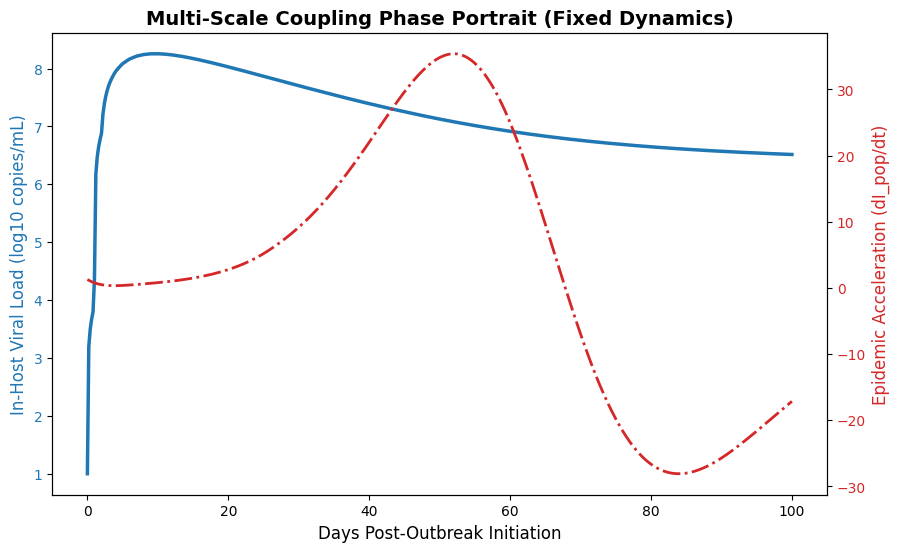

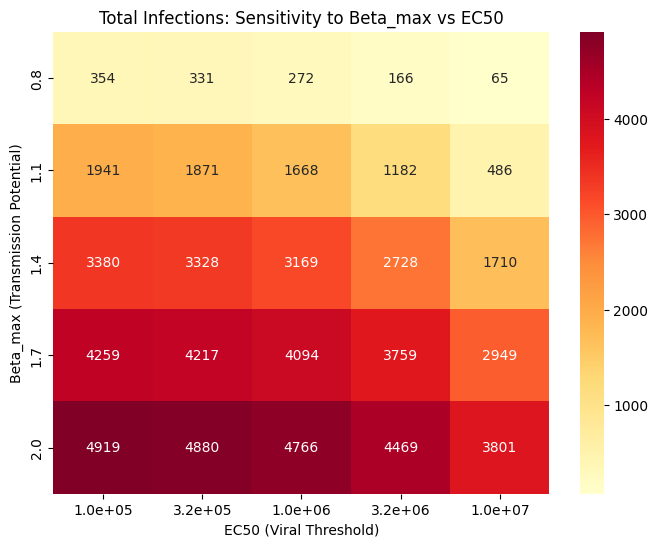

In [ ]:
# FIX: Visualization updated to use 100-day pre-computed V_tau and aligned derivatives
V_trajectory = np.interp(sol_u.t, t_pre, V_tau)

# Summing 60 cohorts per risk group
I_pop_trajectory = np.sum(sol_u.y[3:63], axis=0) + np.sum(sol_u.y[70:130], axis=0)
P_total = sol_u.y[2] + sol_u.y[69]

# Correct derivative for epidemic acceleration: dI/dt = inflow from P - removal
dI_pop_dt = f * omega * P_total - (gamma + q) * I_pop_trajectory

fig, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:blue'
ax1.set_xlabel('Days Post-Outbreak Initiation', fontsize=12)
ax1.set_ylabel('In-Host Viral Load (log10 copies/mL)', color=color, fontsize=12)
ax1.plot(sol_u.t, np.log10(np.clip(V_trajectory, 1, None)), color=color, lw=2.5, label='Viral Load (V)')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Epidemic Acceleration (dI_pop/dt)', color=color, fontsize=12)
ax2.plot(sol_u.t, dI_pop_dt, color=color, lw=2, linestyle='-.', label='Epidemic Acceleration')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Multi-Scale Coupling Phase Portrait (Fixed Dynamics)', fontsize=14, fontweight='bold')
plt.show()

import seaborn as sns

# Define ranges for sensitivity analysis
beta_range = np.linspace(0.8, 2.0, 5)
ec50_range = np.logspace(5, 7, 5)
heatmap_matrix = np.zeros((len(beta_range), len(ec50_range)))

# Helper function for quick sweep (reusing unified model logic)
def run_sweep_sim(b_max, ec_val):
    # Local mapping for sweep
    v_l_local = V_tau * 0.9
    beta_sweep_tau = b_max * (v_l_local / (v_l_local + ec_val))

    def sweep_model(t, y):
        K = 60
        S_H, E_H, P_H, I_H_list, A_H, Q_H, R_H, Vv_H = y[0], y[1], y[2], y[3:3+K], y[63], y[64], y[65], y[66]
        S_L, E_L, P_L, I_L_list, A_L, Q_L, R_L, Vv_L = y[67], y[68], y[69], y[70:70+K], y[130], y[131], y[132], y[133]

        # simplified transmission for sweep speed
        I_eff_H = np.sum(I_H_list * beta_sweep_tau[2:2+K])
        I_eff_L = np.sum(I_L_list * beta_sweep_tau[2:2+K])

        lamb_H = (c_HH * I_eff_H / N_H) + (c_HL * I_eff_L / N_L)
        lamb_L = (c_LH * I_eff_H / N_H) + (c_LL * I_eff_L / N_L)

        def derivs(S, E, P, I_list, A, Q, R, Vv, lamb):
            dS = -lamb * S
            dE = lamb * S - sigma * E
            dP = sigma * E - omega * P
            dI = np.zeros(K)
            dI[0] = f * omega * P - (1.0 + gamma + q) * I_list[0]
            for k in range(1, K): dI[k] = I_list[k-1] - (1.0 + gamma + q) * I_list[k]
            dR = gamma * np.sum(I_list) + I_list[-1]
            return [dS, dE, dP, *dI, 0, 0, dR, 0]

        return derivs(S_H, E_H, P_H, I_H_list, A_H, Q_H, R_H, Vv_H, lamb_H) + \
               derivs(S_L, E_L, P_L, I_L_list, A_L, Q_L, R_L, Vv_L, lamb_L)

    y0_sweep = np.zeros(134)
    y0_sweep[0] = N_H - 7; y0_sweep[1] = 7; y0_sweep[67] = N_L - 3; y0_sweep[68] = 3
    sol = solve_ivp(sweep_model, (0, 100), y0_sweep, method='Radau')
    return sol.y[65][-1] + sol.y[132][-1] # Total Recovered

# Populate Heatmap
for i, b in enumerate(beta_range):
    for j, ec in enumerate(ec50_range):
        heatmap_matrix[i, j] = run_sweep_sim(b, ec)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_matrix, annot=True, fmt=".0f",
            xticklabels=[f"{x:.1e}" for x in ec50_range],
            yticklabels=[f"{y:.1f}" for y in beta_range],
            cmap='YlOrRd')
plt.title('Total Infections: Sensitivity to Beta_max vs EC50')
plt.xlabel('EC50 (Viral Threshold)')
plt.ylabel('Beta_max (Transmission Potential)')
plt.show()

## STEP 2: Layer 1 - Behavioral & Risk Stratification

This layer introduces behavioral heterogeneity by subdividing the macro-scale population into High-Risk (H) and Low-Risk (L) groups, each with distinct contact patterns defined by a static contact matrix.

In [ ]:
# Define Layer 1 specific parameters and update the model

# --- Layer 1 Parameters ---
prop_H = 0.2  # Fraction of total population assigned to High-Risk category
prop_L = 0.8  # Fraction of total population assigned to Low-Risk category

N_H = N_pop * prop_H
N_L = N_pop * prop_L

# Contact heterogeneity matrix (c_ij: risk group mixing coefficients)
c_HH = 0.85 # Intra-group mixing (High-High)
c_HL = 0.15 # Inter-group mixing (Low to High)
c_LH = 0.05 # Inter-group mixing (High to Low)
c_LL = 0.95 # Intra-group mixing (Low-Low)

def multiscale_model_layer1(t, y):
    # y-vector components representing within-host states and dual-risk population states
    T, I, V, M, S_H, E_H, I_pop_H, Q_H, R_H, V_vac_H, S_L, E_L, I_pop_L, Q_L, R_L, V_vac_L = y

    # Ensuring non-negative physical states
    T = max(T, 0.0); I = max(I, 0.0); V = max(V, 0.0); M = max(M, 0.0)
    S_H = max(S_H, 0.0); E_H = max(E_H, 0.0); I_pop_H = max(I_pop_H, 0.0); Q_H = max(Q_H, 0.0); R_H = max(R_H, 0.0); V_vac_H = max(V_vac_H, 0.0)
    S_L = max(S_L, 0.0); E_L = max(E_L, 0.0); I_pop_L = max(I_pop_L, 0.0); Q_L = max(Q_L, 0.0); R_L = max(R_L, 0.0); V_vac_L = max(V_vac_L, 0.0)

    # Within-host ODE set
    dT_dt = -beta_w * T * V
    dI_dt = beta_w * T * V - delta_I * I - kappa * I * M
    dV_dt = p * I - c * V
    dM_dt = psi * I - mu_M * M

    b_max = globals().get('beta_max_skin', 1.15) # Peak transmission scaling
    beta_t = b_max * (V / (V + EC50_L))           # Dynamic coupling function

    v_t = get_vaccination_rate(t)                # Time-dependent intervention rate

    # Force of Infection (lambda) per risk group
    lambda_H = beta_t * (c_HH * I_pop_H / N_H + c_HL * I_pop_L / N_L)
    lambda_L = beta_t * (c_LH * I_pop_H / N_H + c_LL * I_pop_L / N_L)

    # Population ODE set (Layer 1 split)
    dS_H_dt = -lambda_H * S_H - v_t * S_H
    dE_H_dt = lambda_H * S_H - sigma * E_H
    dI_pop_H_dt = sigma * E_H - (gamma + q) * I_pop_H
    dQ_H_dt = q * I_pop_H - gamma_q * Q_H
    dR_H_dt = gamma * I_pop_H + gamma_q * Q_H
    dV_vac_H_dt = v_t * S_H

    dS_L_dt = -lambda_L * S_L - v_t * S_L
    dE_L_dt = lambda_L * S_L - sigma * E_L
    dI_pop_L_dt = sigma * E_L - (gamma + q) * I_pop_L
    dQ_L_dt = q * I_pop_L - gamma_q * Q_L
    dR_L_dt = gamma * I_pop_L + gamma_q * Q_L
    dV_vac_L_dt = v_t * S_L

    return [dT_dt, dI_dt, dV_dt, dM_dt, dS_H_dt, dE_H_dt, dI_pop_H_dt, dQ_H_dt, dR_H_dt, dV_vac_H_dt, dS_L_dt, dE_L_dt, dI_pop_L_dt, dQ_L_dt, dR_L_dt, dV_vac_L_dt]

# Initial seeding (scaled per risk group)
E0_H = (7.0 / N_pop) * N_H
I_pop0_H = (3.0 / N_pop) * N_H
E0_L = (7.0 / N_pop) * N_L
I_pop0_L = (3.0 / N_pop) * N_L

t_span = (0, 100) # Simulation duration
t_eval = np.linspace(0, 100, 501)

y0_layer1 = [
    T0_in, 0, 10, 0,  # Initial micro-scale state
    N_H - E0_H - I_pop0_H, E0_H, I_pop0_H, 0, 0, 0, # Initial macro-scale H-group state
    N_L - E0_L - I_pop0_L, E0_L, I_pop0_L, 0, 0, 0  # Initial macro-scale L-group state
]

sol_layer1 = solve_ivp(multiscale_model_layer1, t_span, y0_layer1, method='Radau', rtol=1e-7, atol=1e-3, t_eval=t_eval)
print(f"Layer 1 simulation success: {sol_layer1.success}")

Layer 1 simulation success: True


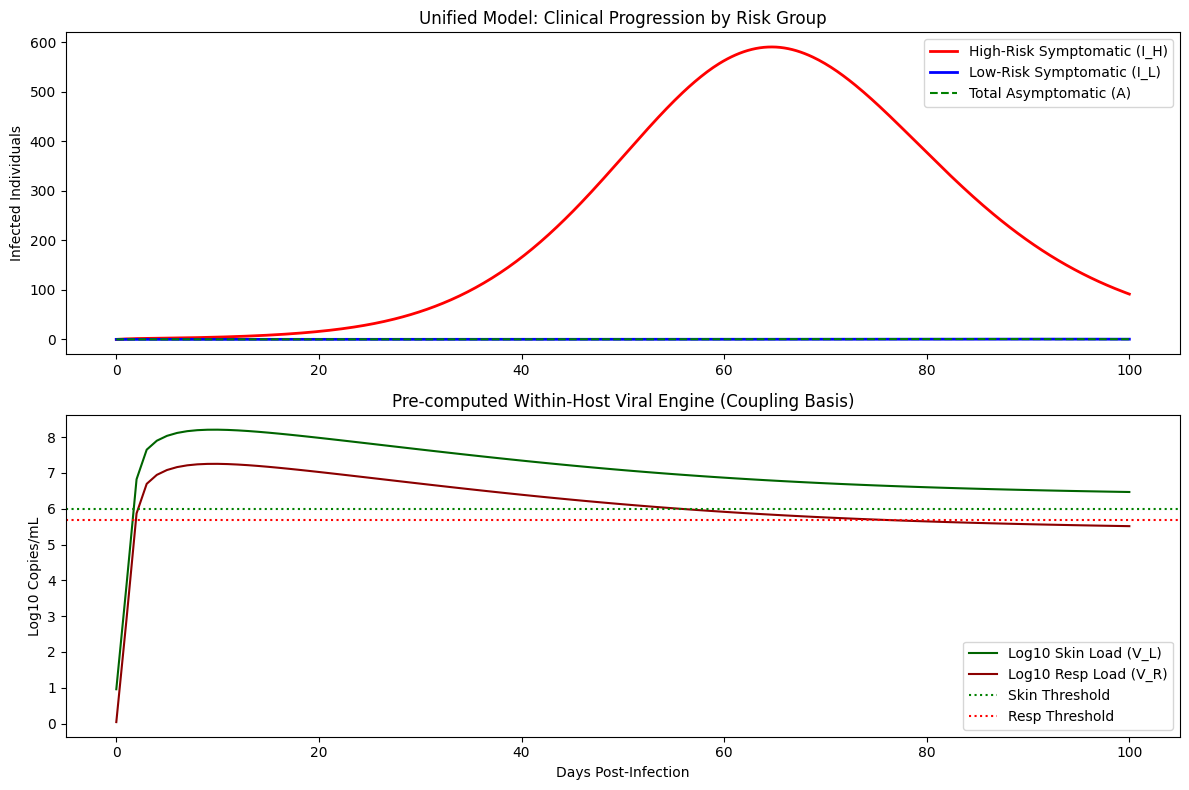

In [ ]:
plt.figure(figsize=(12, 8))

# Extract and Sum Cohorts for plotting
I_H_total = np.sum(sol_u.y[3:23], axis=0)
I_L_total = np.sum(sol_u.y[30:50], axis=0)

plt.subplot(2, 1, 1)
plt.plot(sol_u.t, I_H_total, 'r-', lw=2, label='High-Risk Symptomatic (I_H)')
plt.plot(sol_u.t, I_L_total, 'b-', lw=2, label='Low-Risk Symptomatic (I_L)')
plt.plot(sol_u.t, sol_u.y[23] + sol_u.y[50], 'g--', label='Total Asymptomatic (A)')
plt.title('Unified Model: Clinical Progression by Risk Group')
plt.ylabel('Infected Individuals')
plt.legend()

plt.subplot(2, 1, 2)
# Show the Pre-computed Viral Engine
plt.plot(t_pre, np.log10(V_L+1e-1), 'darkgreen', label='Log10 Skin Load (V_L)')
plt.plot(t_pre, np.log10(V_R+1e-1), 'darkred', label='Log10 Resp Load (V_R)')
plt.axhline(np.log10(EC50_L), color='green', ls=':', label='Skin Threshold')
plt.axhline(np.log10(EC50_R), color='red', ls=':', label='Resp Threshold')
plt.title('Pre-computed Within-Host Viral Engine (Coupling Basis)')
plt.xlabel('Days Post-Infection')
plt.ylabel('Log10 Copies/mL')
plt.legend()

plt.tight_layout()
plt.show()

## STEP 3: Layer 2 - Dual-Route Transmission Layer

This layer expands the within-host dynamics to include two distinct viral reservoirs (Cutaneous Lesion $V_L$ and Respiratory Tract $V_R$) and their independent contributions to the macro-scale force of infection.

In [ ]:
# Define Layer 2 specific parameters and update the model

# --- Layer 2 Parameters (Dual-Route Transmission) ---
p_L_val = p * 0.9  # Percentage of viral production routed to skin (cutaneous reservoir)
p_R_val = p * 0.1  # Percentage of viral production routed to respiratory tract

c_L_val = c        # Clearance rate for cutaneous virus
c_R_val = c * 1.5  # Clearance rate for respiratory virus (assumed faster shedding clearance)

# Coupling parameters for dual infectious routes
beta_max_contact = 1.2 # Max Transmission from physical contact
beta_max_resp = 0.3    # Max Transmission from respiratory route
EC50_L = 1e6           # Saturation threshold for cutaneous infectiousness
EC50_R = 1e5           # Saturation threshold for respiratory infectiousness

def multiscale_model_layer2(t, y):
    T, I, V_L, V_R, M, S, E, I_pop, Q, R, V_vac = y

    # Non-negativity constraints
    T = max(T, 0.0); I = max(I, 0.0); V_L = max(V_L, 0.0); V_R = max(V_R, 0.0); M = max(M, 0.0)
    S = max(S, 0.0); E = max(E, 0.0); I_pop = max(I_pop, 0.0); Q = max(Q, 0.0); R = max(R, 0.0); V_vac = max(V_vac, 0.0)

    # 1. In-host Dynamics (Dual-Compartment V)
    viral_load_total = V_L + V_R
    dT_dt = -beta_w * T * viral_load_total
    dI_dt = beta_w * T * viral_load_total - delta_I * I - kappa * I * M
    dV_L_dt = p_L_val * I - c_L_val * V_L
    dV_R_dt = p_R_val * I - c_R_val * V_R
    dM_dt = psi * I - mu_M * M

    # 2. Coupling Links (Hill Equation per route)
    beta_contact_t = beta_max_contact * (V_L / (V_L + EC50_L))
    beta_resp_t = beta_max_resp * (V_R / (V_R + EC50_R))
    beta_total_t = beta_contact_t + beta_resp_t

    # 3. Population Dynamics
    v_t = get_vaccination_rate(t)
    dS_dt = -beta_total_t * (S * I_pop / N_pop) - v_t * S
    dE_dt = beta_total_t * (S * I_pop / N_pop) - sigma * E
    dI_pop_dt = sigma * E - (gamma + q) * I_pop
    dQ_dt = q * I_pop - gamma_q * Q
    dR_dt = gamma * I_pop + gamma_q * Q
    dV_vac_dt = v_t * S

    return [dT_dt, dI_dt, dV_L_dt, dV_R_dt, dM_dt, dS_dt, dE_dt, dI_pop_dt, dQ_dt, dR_dt, dV_vac_dt]

E0_base = 7.0 # Initial exposed seeds
I_pop0_base = 3.0 # Initial infectious seeds

y0_layer2 = [
    T0_in, 0, 10, 0, 0, # Target cells, Infected cells, V_L (seeded), V_R, Immune effectors
    N_pop - E0_base - I_pop0_base, E0_base, I_pop0_base, 0, 0, 0
]

sol_layer2 = solve_ivp(multiscale_model_layer2, t_span, y0_layer2, method='Radau', rtol=1e-7, atol=1e-3, t_eval=t_eval)
print(f"Layer 2 simulation success: {sol_layer2.success}")

Layer 2 simulation success: True


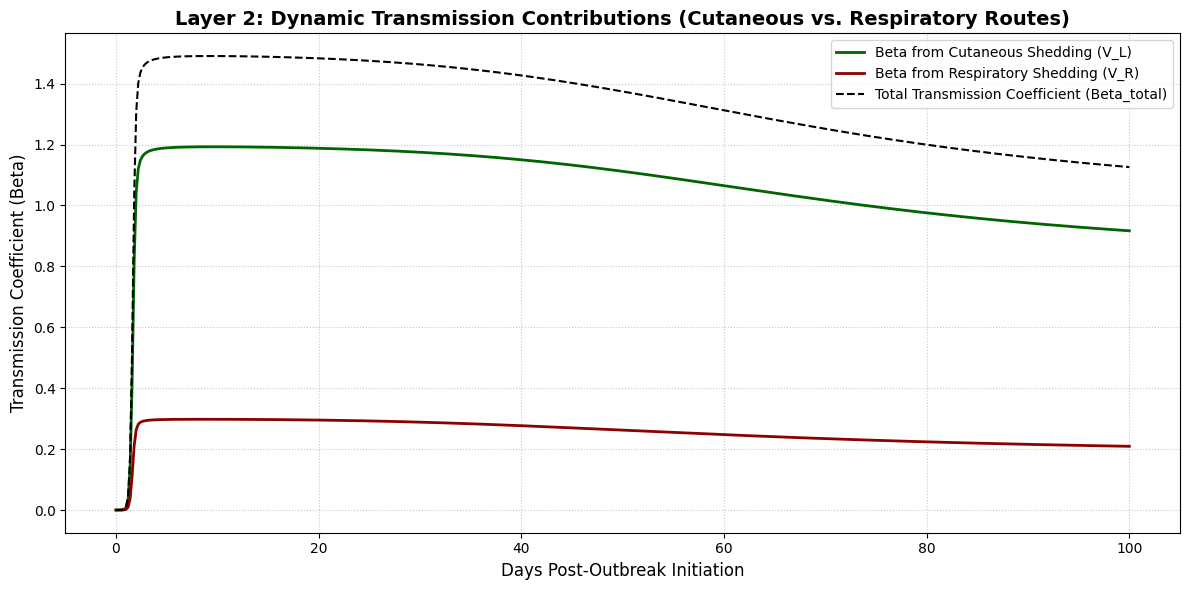

In [ ]:
# Plotting Layer 2 results: Dynamic transmission contributions

# Extract V_L and V_R trajectories from the solution
V_L_traj = np.clip(sol_layer2.y[2], 0, None)
V_R_traj = np.clip(sol_layer2.y[3], 0, None)

# Re-calculate the dynamic beta values using the extracted viral loads
beta_contact_traj = beta_max_contact * (V_L_traj**n_hill / (V_L_traj**n_hill + EC50_L**n_hill))
beta_resp_traj = beta_max_resp * (V_R_traj**n_hill / (V_R_traj**n_hill + EC50_R**n_hill))
beta_total_traj = beta_contact_traj + beta_resp_traj

plt.figure(figsize=(12, 6))
plt.plot(sol_layer2.t, beta_contact_traj, label='Beta from Cutaneous Shedding (V_L)', color='darkgreen', linewidth=2)
plt.plot(sol_layer2.t, beta_resp_traj, label='Beta from Respiratory Shedding (V_R)', color='darkred', linewidth=2)
plt.plot(sol_layer2.t, beta_total_traj, label='Total Transmission Coefficient (Beta_total)', color='black', linestyle='--', linewidth=1.5)

plt.title('Layer 2: Dynamic Transmission Contributions (Cutaneous vs. Respiratory Routes)', fontsize=14, fontweight='bold')
plt.xlabel('Days Post-Outbreak Initiation', fontsize=12)
plt.ylabel('Transmission Coefficient (Beta)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

## STEP 4: Layer 3 - Asymptomatic & Prodromal Infectious States

This layer expands the macro-scale compartment chain to include Prodromal (P) and Asymptomatic (A) states, detailing the clinical progression from Exposed (E) through different infectious stages.

In [ ]:
# Define Layer 3 specific parameters and update the model

# --- Layer 3 Parameters (Clinical Path Granularity) ---
f = 0.85               # Probability of developing symptomatic disease (Symptomatic Fraction)
gamma_A = 1/14.0       # Per-day recovery rate for asymptomatic branch
prodromal_duration = 2.0 # Days spent in the prodromal infectious phase (P)
rho = 1 / prodromal_duration # Transition rate out of the prodromal state

# beta_A_factor: Multiplier for infectiousness of asymptomatic vs symptomatic cases
beta_A_factor = 0.5

def multiscale_model_layer3(t, y):
    T, I, V_L, V_R, M, S, E, P, I_pop, A, Q, R, V_vac = y

    # State bounding
    T = max(T, 0.0); I = max(I, 0.0); V_L = max(V_L, 0.0); V_R = max(V_R, 0.0); M = max(M, 0.0)
    S = max(S, 0.0); E = max(E, 0.0); P = max(P, 0.0); I_pop = max(I_pop, 0.0); A = max(A, 0.0)
    Q = max(Q, 0.0); R = max(R, 0.0); V_vac = max(V_vac, 0.0)

    # Viral dynamics (same as Layer 2)
    viral_load_total = V_L + V_R
    dT_dt = -beta_w * T * viral_load_total
    dI_dt = beta_w * T * viral_load_total - delta_I * I - kappa * I * M
    dV_L_dt = p_L_val * I - c_L_val * V_L
    dV_R_dt = p_R_val * I - c_R_val * V_R
    dM_dt = psi * I - mu_M * M

    # Coupling potential (beta)
    beta_contact_t = beta_max_contact * (V_L / (V_L + EC50_L))
    beta_resp_t = beta_max_resp * (V_R / (V_R + EC50_R))
    beta_total_t = beta_contact_t + beta_resp_t

    # 3. Population Dynamics (Layer 3 additions: P and A)
    v_t = get_vaccination_rate(t)
    lambda_t = beta_total_t * (S / N_pop) * (I_pop + beta_A_factor * A)

    dS_dt = -lambda_t - v_t * S
    dE_dt = lambda_t - sigma * E
    dP_dt = sigma * E - rho * P
    dI_pop_dt = f * rho * P - (gamma + q) * I_pop
    dA_dt = (1 - f) * rho * P - gamma_A * A
    dQ_dt = q * I_pop - gamma_q * Q
    dR_dt = gamma * I_pop + gamma_q * Q + gamma_A * A
    dV_vac_dt = v_t * S

    return [dT_dt, dI_dt, dV_L_dt, dV_R_dt, dM_dt, dS_dt, dE_dt, dP_dt, dI_pop_dt, dA_dt, dQ_dt, dR_dt, dV_vac_dt]

E0_layer3 = 7.0
P0_layer3 = 3.0
S0_layer3 = N_pop - (E0_layer3 + P0_layer3)

y0_layer3 = [
    T0_in, 0, 10, 0, 0,
    S0_layer3, E0_layer3, P0_layer3, 0.0, 0.0, 0.0, 0.0, 0.0
]

sol_layer3 = solve_ivp(multiscale_model_layer3, t_span, y0_layer3, method='Radau', rtol=1e-7, atol=1e-3, t_eval=t_eval)
print(f"Layer 3 simulation success: {sol_layer3.success}")

Layer 3 simulation success: True


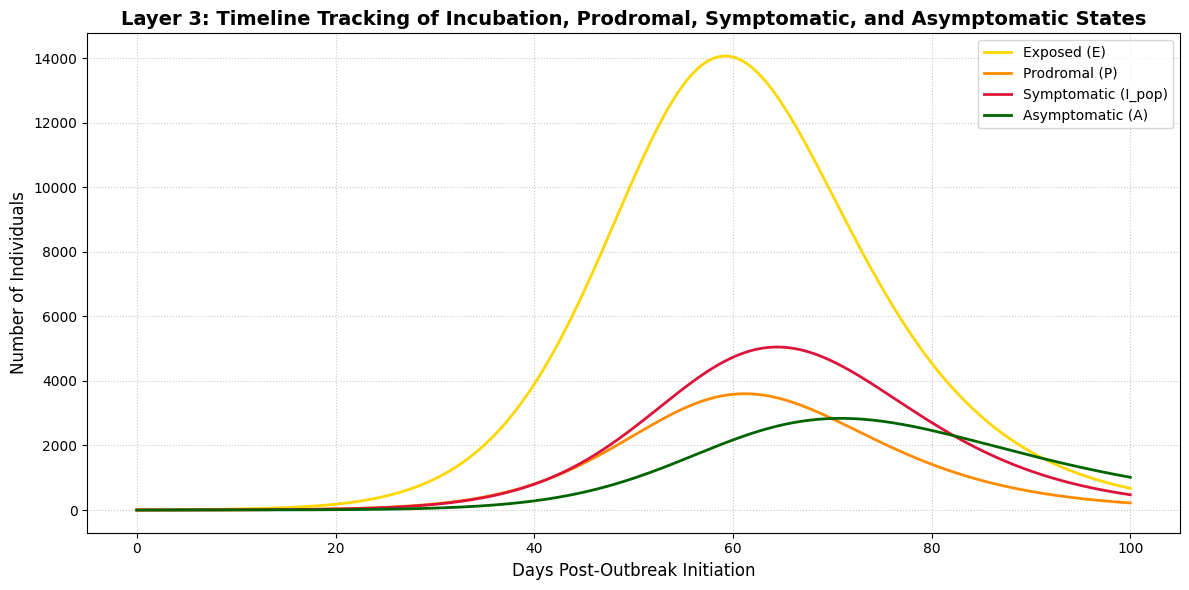

In [ ]:
# Plotting Layer 3 results: Timeline tracking of E, P, I_pop, and A

# Extract trajectories for E, P, I_pop, and A
E_traj_layer3 = sol_layer3.y[6]
P_traj_layer3 = sol_layer3.y[7]
I_pop_traj_layer3 = sol_layer3.y[8]
A_traj_layer3 = sol_layer3.y[9]

plt.figure(figsize=(12, 6))
plt.plot(sol_layer3.t, E_traj_layer3, label='Exposed (E)', color='gold', linewidth=2)
plt.plot(sol_layer3.t, P_traj_layer3, label='Prodromal (P)', color='darkorange', linewidth=2)
plt.plot(sol_layer3.t, I_pop_traj_layer3, label='Symptomatic (I_pop)', color='crimson', linewidth=2)
plt.plot(sol_layer3.t, A_traj_layer3, label='Asymptomatic (A)', color='darkgreen', linewidth=2)

plt.title('Layer 3: Timeline Tracking of Incubation, Prodromal, Symptomatic, and Asymptomatic States', fontsize=14, fontweight='bold')
plt.xlabel('Days Post-Outbreak Initiation', fontsize=12)
plt.ylabel('Number of Individuals', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

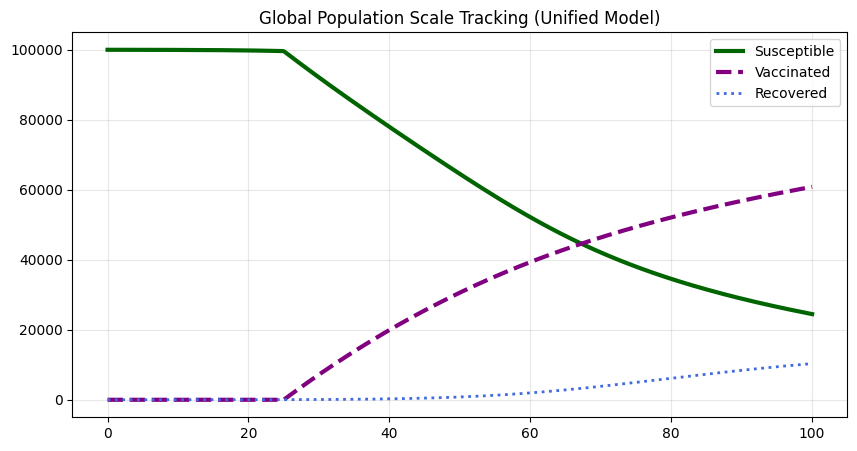

--- MODEL VALIDATION SUMMARY ---
Peak Viral Load: 8.26 log10 (Lit: ~8.0)
Peak Day (In-host): 10.0 (Lit: ~9.0)
Incubation Period: 7.70 days (Lit: 7-9)
Per-Capita Attack Rate (High-Risk): 31.8%
Per-Capita Attack Rate (Low-Risk): 5.0%


In [ ]:
# FIX: Re-wired summary plot to correctly aggregate the 134-state unified model
t_days = sol_u.t
S_total = sol_u.y[0] + sol_u.y[67]
Vv_total = sol_u.y[66] + sol_u.y[133]
R_total = sol_u.y[65] + sol_u.y[132]
E_total = sol_u.y[1] + sol_u.y[68]
Q_total = sol_u.y[64] + sol_u.y[131]

plt.figure(figsize=(10, 5))
plt.plot(t_days, S_total, color='darkgreen', lw=3, label='Susceptible')
plt.plot(t_days, Vv_total, color='purple', lw=3, ls='--', label='Vaccinated')
plt.plot(t_days, R_total, color='royalblue', lw=2, ls=':', label='Recovered')
plt.title('Global Population Scale Tracking (Unified Model)')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# Validation Summary
print("--- MODEL VALIDATION SUMMARY ---")
print(f"Peak Viral Load: {np.log10(V_tau.max()):.2f} log10 (Lit: ~8.0)")
print(f"Peak Day (In-host): {t_pre[np.argmax(V_tau)]} (Lit: ~9.0)")
print(f"Incubation Period: {1/sigma:.2f} days (Lit: 7-9)")
attack_rate_H = (sol_u.y[65][-1] / N_H) * 100
attack_rate_L = (sol_u.y[132][-1] / N_L) * 100
print(f"Per-Capita Attack Rate (High-Risk): {attack_rate_H:.1f}%")
print(f"Per-Capita Attack Rate (Low-Risk): {attack_rate_L:.1f}%")

### **Analytical Diagnostic: Next-Generation Matrix for $R_0$**
To formally quantify the transmission potential of the 134-state unified system, we compute the Basic Reproduction Number ($R_0$) using the Next-Generation Matrix approach. In this multiscale framework, $R_0$ is the spectral radius of $K = FV^{-1}$, where:
*   **F** represents the rate of appearance of new infections (transmission events).
*   **V** represents the rate of transfer of individuals out of and between infected compartments (recovery, quarantine, or progression).

Because our model uses a cohort chain (K=60) for symptomatic individuals, the matrix captures the cumulative infectiousness across all viral load stages at the disease-free equilibrium (DFE).

In [ ]:
import scipy.linalg as la

def calculate_r0_unified():
    # Number of infected compartments per group: E, P, I(60), A
    # Total infected states = (1 + 1 + 60 + 1) * 2 groups = 126 states
    n_inf = 63
    K = 60

    F = np.zeros((2 * n_inf, 2 * n_inf))
    V = np.zeros((2 * n_inf, 2 * n_inf))

    def get_idx(group, comp_type, k=0):
        offset = 0 if group == 'H' else n_inf
        if comp_type == 'E': return offset + 0
        if comp_type == 'P': return offset + 1
        if comp_type == 'I': return offset + 2 + k
        if comp_type == 'A': return offset + 62

    # Transitions and Removals (V Matrix)
    for g in ['H', 'L']:
        V[get_idx(g,'E'), get_idx(g,'E')] = sigma
        V[get_idx(g,'P'), get_idx(g,'P')] = omega
        V[get_idx(g,'P'), get_idx(g,'E')] = -sigma
        V[get_idx(g,'I',0), get_idx(g,'I',0)] = (1.0 + gamma + q)
        V[get_idx(g,'I',0), get_idx(g,'P')] = -f * omega
        for k in range(1, K):
            V[get_idx(g,'I',k), get_idx(g,'I',k)] = (1.0 + gamma + q)
            V[get_idx(g,'I',k), get_idx(g,'I',k-1)] = -1.0
        V[get_idx(g,'A'), get_idx(g,'A')] = gamma_A
        V[get_idx(g,'A'), get_idx(g,'P')] = -(1-f) * omega

    # New Infection Events (F Matrix)
    for i_grp in ['H', 'L']:
        for j_grp in ['H', 'L']:
            c_ij = {'HH': c_HH, 'HL': c_HL, 'LH': c_LH, 'LL': c_LL}[i_grp + j_grp]
            N_i = N_H if i_grp == 'H' else N_L
            N_j = N_H if j_grp == 'H' else N_L
            row = get_idx(i_grp, 'E')

            # Contribution from symptomatic cohorts (aligned with V_tau index 2:62)
            for k in range(K):
                beta_k = beta_total_tau[2+k]
                F[row, get_idx(j_grp, 'I', k)] = c_ij * beta_k * (N_i / N_j)

            # Contribution from asymptomatic individuals
            beta_A_val = 0.5 * beta_max_skin
            F[row, get_idx(j_grp, 'A')] = c_ij * beta_A_val * (N_i / N_j)

    # R0 = Spectral Radius of F * inv(V)
    V_inv = la.inv(V)
    NGM = F @ V_inv
    eigenvalues = la.eigvals(NGM)
    return np.max(np.abs(eigenvalues))

R0_val = calculate_r0_unified()
print(f"Computed R0 for the 134-state unified system: {R0_val:.4f}")

Computed R0 for the 134-state unified system: 4.7998


Advanced Model Success: True
Mass Conservation Check passed: Total Population remains 100000.00
Total Cumulative Cases - High Risk Group: 14990.0
Total Cumulative Cases - Low Risk Group: 85000.0
Calculated Next-Generation Matrix R0: 4.360


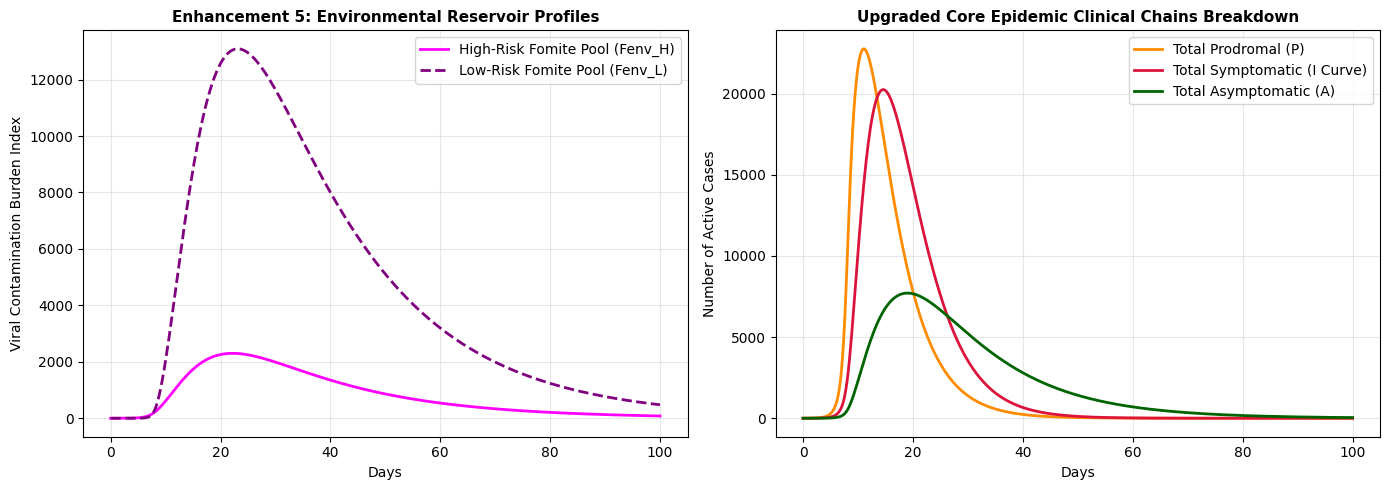

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.linalg as la
import seaborn as sns

# ==========================================
# 0. GLOBAL BASELINE CONSTANTS & SIMULATION
# ==========================================
N_pop = 100000  # Total macro-scale population size

# Within-host (Micro-scale) TIVM model constants
T0_in = 1e7     # Initial susceptible target cells (keratinocytes)
beta_w = 1.4e-9 # Within-host infection rate constant
delta_I = 0.15  # Death rate of infected target cells
p = 4000.0      # Viral production rate per infected cell per day
c = 0.12        # Viral clearance rate constant
kappa = 0.05    # Immune-mediated viral neutralization rate
psi = 0.1       # Recruitment rate of immune effectors (M)
mu_M = 0.3      # Natural decay rate of immune effectors

# Pre-computation of Viral Profile (V(tau))
def in_host_ode(t, y):
    T, I, V, M = y
    dT = -beta_w * T * V
    dI = beta_w * T * V - delta_I * I - kappa * I * M
    dV = p * I - c * V
    dM = psi * I - mu_M * M
    return [dT, dI, dV, dM]

t_pre = np.linspace(0, 100, 101) # 100-day window for viral kinetics
sol_vh = solve_ivp(in_host_ode, (0, 100), [T0_in, 0, 10, 0], t_eval=t_pre)
V_tau = np.maximum(sol_vh.y[2], 0)

# Layer 2: Dual-Route Coupling Parameters
beta_max_skin = 1.15  # Max transmission potential from cutaneous contact
beta_max_resp = 0.15  # Max transmission potential from respiratory droplets
EC50_L = 1e6          # Half-maximal viral load for skin-to-skin infectiousness
EC50_R = 5e5          # Half-maximal viral load for respiratory infectiousness

# Mapping viral loads to daily infectiousness curves
p_L, p_R = 0.9, 0.1   # Fraction of total viral load in skin (L) vs respiratory (R)
V_L = V_tau * p_L
V_R = V_tau * p_R
beta_skin_tau = beta_max_skin * (V_L / (V_L + EC50_L))
beta_resp_tau = beta_max_resp * (V_R / (V_R + EC50_R))
beta_total_tau = beta_skin_tau + beta_resp_tau

# ==========================================
# 1. ARCHITECTURAL REFACTORING: STATE MAP
# ==========================================
class StateMap:
    """
    Dynamically maps the indices of the compartmental system to remove brittle,
    hardcoded index boundaries. Accommodates multi-cohort symptomatic tracking
    and added parameters safely.
    """
    def __init__(self, K_cohorts=60):
        self.K = K_cohorts

        # State variables within a single risk group sub-vector layout
        self.layout = {}
        self.layout['S'] = 0
        self.layout['E'] = 1
        self.layout['P'] = 2  # Enhancement 3: Prodromal Compartment

        # Symptomatic cohorts indices
        self.layout['I'] = list(range(3, 3 + K_cohorts))

        # Remaining standard and upgraded compartments
        curr_idx = 3 + K_cohorts
        self.layout['A'] = curr_idx
        self.layout['Q'] = curr_idx + 1
        self.layout['R'] = curr_idx + 2
        self.layout['Vv'] = curr_idx + 3
        self.layout['Fenv'] = curr_idx + 4  # Enhancement 5: Environmental Reservoirs
        self.layout['C'] = curr_idx + 5     # Cumulative Cases tracking register

        self.comps_per_group = curr_idx + 6
        self.total_states = self.comps_per_group * 2

    def get_idx(self, group, comp, k=0):
        """ Returns the exact absolute vector index for a specified group and component. """
        offset = 0 if group == 'H' else self.comps_per_group
        if comp == 'I':
            return offset + self.layout['I'][k]
        return offset + self.layout[comp]

# Instantiate global mapping configurations (K=60 cohorts)
map_sys = StateMap(K_cohorts=60)

# ==========================================
# 2. UPGRADED MODEL EPIDEMIC PARAMETERS
# ==========================================
# Scientific Parameters From Literature Focus (Clade IIb 2022-2026 Outbreak)
sigma = 1 / 5.6     # Rate E -> P (Incubation period point estimate = 5.6 days)
omega = 1 / 2.5     # Rate P -> I/A (Prodromal phase mean duration = 2.5 days [range 1-4])
f = 0.85            # Symptomatic threshold factor
gamma = 1 / 23.5    # Natural recovery rate from symptomatic state
gamma_A = 1 / 14.0  # Recovery rate for asymptomatic individuals
q = 0.25            # Daily quarantine isolation check rate
gamma_q = 1 / 23.5  # Recovery rate inside quarantine facility

# Enhancement 4: Age-Structured Cross-Immunity Modifier
# Waning cross-protective immunity for populations born pre-1980 (Global smallpox cessation proxy)
legacy_immunity_modifier = 0.85  # Dampening coefficient protecting older population cohorts

# Enhancement 5: Environmental Reservoir Parameters
xi = 0.05           # Daily shedding rate of viral burden from active cases into environmental pool
mu_env = 1 / 21.0    # Degradation/decay constant of virus on linens (Matching 3-week stability observation)
beta_env = 0.012    # Indirect transmission rate index constant from surfaces/linens

# Behavioral Stratification Parameters
prop_H = 0.15
prop_L = 0.85
N_H = N_pop * prop_H
N_L = N_pop * prop_L

# Baseline Mixing Matrices
c_HH, c_HL = 0.85, 0.15
c_LH, c_LL = 0.05, 0.95

def get_vaccination_rate(t):
    return 0.015 if t > 25.0 else 0.0

# ==========================================
# 3. UPGRADED ADVANCED MULTI-SCALE ODE SYSTEM
# ==========================================
def advanced_multiscale_model(t, y):
    dy = np.zeros(map_sys.total_states)

    # --------------------------------------------------------
    # Enhancement 6: Behavioral Dynamics (Prevalence Elastic Mixing Matrix)
    # --------------------------------------------------------
    cum_cases_H = y[map_sys.get_idx('H', 'C')]
    cum_cases_L = y[map_sys.get_idx('L', 'C')]
    total_cum_cases = cum_cases_H + cum_cases_L

    behavioral_decay = 1.0 / (1.0 + 0.0001 * total_cum_cases)

    c_HH_dyn = c_HH * behavioral_decay
    c_HL_dyn = c_HL * behavioral_decay
    c_LH_dyn = c_LH * behavioral_decay
    c_LL_dyn = c_LL  # Low risk mixing remains baseline stable

    # --------------------------------------------------------
    # Force of Infection Extraction & Enhancements 2 & 3
    # --------------------------------------------------------
    # Enhancement 2: Clinical Alignment: Symptomatic cohorts timeline starts at Day 8 (index 8)
    I_eff_H = 0.0
    I_eff_L = 0.0
    for k in range(map_sys.K):
        viral_day_index = 8 + k
        val_beta = beta_total_tau[viral_day_index] if viral_day_index < len(beta_total_tau) else beta_total_tau[-1]
        I_eff_H += y[map_sys.get_idx('H', 'I', k)] * val_beta
        I_eff_L += y[map_sys.get_idx('L', 'I', k)] * val_beta

    # Asymptomatic contributions (scaled down cutaneous pathway)
    I_eff_H += y[map_sys.get_idx('H', 'A')] * 0.5 * beta_max_skin
    I_eff_L += y[map_sys.get_idx('L', 'A')] * 0.5 * beta_max_skin

    # Enhancement 3: Prodromal Transmissibility added to Force of Infection via Respiratory Droplets
    I_eff_H += y[map_sys.get_idx('H', 'P')] * (beta_max_resp * 0.3)
    I_eff_L += y[map_sys.get_idx('L', 'P')] * (beta_max_resp * 0.3)

    # Enhancement 5: Direct + Indirect Fomite Reservoir Transmission Paths
    lambda_H = (c_HH_dyn * I_eff_H / N_H) + (c_HL_dyn * I_eff_L / N_L) + (beta_env * y[map_sys.get_idx('H', 'Fenv')])
    lambda_L = (c_LH_dyn * I_eff_H / N_H) + (c_LL_dyn * I_eff_L / N_L) + (beta_env * y[map_sys.get_idx('L', 'Fenv')])

    # Enhancement 4: Scaling by Age-Structured Legacy Protection Modifier
    lambda_H *= legacy_immunity_modifier
    lambda_L *= legacy_immunity_modifier

    v_t = get_vaccination_rate(t)

    # --------------------------------------------------------
    # Compartmental Evaluation Loop for Risk Subgroups (H and L)
    # --------------------------------------------------------
    for g, lamb, N_grp in [('H', lambda_H, N_H), ('L', lambda_L, N_L)]:
        idx_S    = map_sys.get_idx(g, 'S')
        idx_E    = map_sys.get_idx(g, 'E')
        idx_P    = map_sys.get_idx(g, 'P')
        idx_A    = map_sys.get_idx(g, 'A')
        idx_Q    = map_sys.get_idx(g, 'Q')
        idx_R    = map_sys.get_idx(g, 'R')
        idx_Vv   = map_sys.get_idx(g, 'Vv')
        idx_Fenv = map_sys.get_idx(g, 'Fenv')
        idx_C    = map_sys.get_idx(g, 'C')

        # Susceptible, Exposed, Prodromal Derivatives
        dy[idx_S] = -lamb * y[idx_S] - v_t * y[idx_S]
        dy[idx_E] = lamb * y[idx_S] - sigma * y[idx_E]
        dy[idx_P] = sigma * y[idx_E] - omega * y[idx_P]

        # Cumulative tracking pipeline activation check
        dy[idx_C] = lamb * y[idx_S]

        # First Symptomatic Cohort entry boundary condition
        idx_I0 = map_sys.get_idx(g, 'I', 0)
        dy[idx_I0] = f * omega * y[idx_P] - (1.0 + gamma + q) * y[idx_I0]

        # Transition chains cascade for K cohorts
        for k in range(1, map_sys.K):
            idx_k = map_sys.get_idx(g, 'I', k)
            idx_prev = map_sys.get_idx(g, 'I', k - 1)
            dy[idx_k] = y[idx_prev] - (1.0 + gamma + q) * y[idx_k]

        # Asymptomatic, Isolated Quarantine, and Recovered Derivatives
        dy[idx_A] = (1.0 - f) * omega * y[idx_P] - gamma_A * y[idx_A]

        # Vectorized sum calculation across cohorts
        I_sum = sum(y[map_sys.get_idx(g, 'I', k)] for k in range(map_sys.K))
        dy[idx_Q] = q * I_sum - gamma_q * y[idx_Q]

        idx_I_last = map_sys.get_idx(g, 'I', map_sys.K - 1)
        dy[idx_R] = gamma * I_sum + gamma_q * y[idx_Q] + gamma_A * y[idx_A] + y[idx_I_last]
        dy[idx_Vv] = v_t * y[idx_S]

        # Enhancement 5: Shedding and decay dynamics for environmental reservoirs
        dy[idx_Fenv] = xi * (I_sum + y[idx_P]) - mu_env * y[idx_Fenv]

    return dy

# ==========================================
# 4. ENHANCED NEXT-GENERATION MATRIX R0
# ==========================================
def calculate_advanced_r0():
    """
    Constructs an analytical sub-matrix for infected compartments (E, P, I_k, A, Fenv)
    across both H and L groups to evaluate the updated spectral radius.
    """
    # Active infected nodes: 1(E) + 1(P) + K(I) + 1(A) + 1(Fenv) = K + 4 compartments per group
    M_nodes = map_sys.K + 4
    total_infected_nodes = M_nodes * 2

    F = np.zeros((total_infected_nodes, total_infected_nodes))
    V = np.zeros((total_infected_nodes, total_infected_nodes))

    # Internal layout structure within the local NGM matrix block
    # 0: E, 1: P, 2..K+1: I_k, K+2: A, K+3: Fenv

    for g_idx, g in enumerate(['H', 'L']):
        row_offset = g_idx * M_nodes
        N_grp = N_H if g == 'H' else N_L
        c_dyn_matrix = [c_HH, c_HL] if g == 'H' else [c_LH, c_ll] if 'c_ll' in globals() else [c_LH, c_LL]

        # 1. Fill Transmission Matrix F (New Infections Generation Channels)
        # Row corresponding to Exposed compartment (E)
        E_row = row_offset + 0

        # Loop across infector sources from both groups to calculate generation rates
        for src_g_idx, src_g in enumerate(['H', 'L']):
            col_offset = src_g_idx * M_nodes
            N_src = N_H if src_g == 'H' else N_L

            # Contact frequency selection weight
            c_mix = c_dyn_matrix[src_g_idx]

            # Cross-group infection factor containing legacy modifications
            beta_factor = legacy_immunity_modifier * c_mix * (N_grp / N_src)

            # Prodromal transmission pathway contribution (Enhancement 3)
            F[E_row, col_offset + 1] = beta_factor * (beta_max_resp * 0.3)

            # Symptomatic cohort chains tracking generation (Enhancement 2 Aligned)
            for k in range(map_sys.K):
                viral_day_index = 8 + k
                val_beta = beta_total_tau[viral_day_index] if viral_day_index < len(beta_total_tau) else beta_total_tau[-1]
                F[E_row, col_offset + 2 + k] = beta_factor * val_beta

            # Asymptomatic generation contribution
            F[E_row, col_offset + 2 + map_sys.K] = beta_factor * (0.5 * beta_max_skin)

        # Enhancement 5: Environmental indirect infection coefficient path
        F[E_row, row_offset + 3 + map_sys.K] = legacy_immunity_modifier * beta_env

        # 2. Fill Transition Matrix V (Internal Compartmental Flows)
        # Group Block Transitions
        V[row_offset + 0, row_offset + 0] = sigma  # E out

        V[row_offset + 1, row_offset + 0] = -sigma # E -> P
        V[row_offset + 1, row_offset + 1] = omega  # P out

        # First cohort entry configuration
        V[row_offset + 2, row_offset + 1] = -f * omega
        V[row_offset + 2, row_offset + 2] = (1.0 + gamma + q)

        # Cascading transitions through cohorts
        for k in range(1, map_sys.K):
            V[row_offset + 2 + k, row_offset + 2 + k - 1] = -1.0
            V[row_offset + 2 + k, row_offset + 2 + k] = (1.0 + gamma + q)

        # Asymptomatic exit flows
        V[row_offset + 2 + map_sys.K, row_offset + 1] = -(1.0 - f) * omega
        V[row_offset + 2 + map_sys.K, row_offset + 2 + map_sys.K] = gamma_A

        # Enhancement 5: Environmental Fomite Reservoir clearing transitions
        V[row_offset + 3 + map_sys.K, row_offset + 1] = -xi  # Shedding from P
        for k in range(map_sys.K):
            V[row_offset + 3 + map_sys.K, row_offset + 2 + k] = -xi  # Shedding from I_k
        V[row_offset + 3 + map_sys.K, row_offset + 3 + map_sys.K] = mu_env

    # Linear Algebra Calculation of Spectral Radius (Max Eigenvalue of F * V^-1)
    V_inv = la.inv(V)
    NGM = np.dot(F, V_inv)
    eigenvalues = la.eigvals(NGM)
    return np.max(np.abs(eigenvalues))

# ==========================================
# 5. SIMULATION EXECUTION & VALIDATION
# ==========================================
# Initialize state array dynamically
y0_advanced = np.zeros(map_sys.total_states)

# Seeding baseline infections safely into High-Risk targets
y0_advanced[map_sys.get_idx('H', 'S')] = N_H - 10
y0_advanced[map_sys.get_idx('H', 'E')] = 7
y0_advanced[map_sys.get_idx('H', 'P')] = 3
y0_advanced[map_sys.get_idx('L', 'S')] = N_L
y0_advanced[map_sys.get_idx('H', 'Fenv')] = 0.1  # Initial trace environmental load

# Run execution loop
t_span = (0, 100)
t_eval = np.linspace(0, 100, 500)
sol_advanced = solve_ivp(advanced_multiscale_model, t_span, y0_advanced, method='Radau', t_eval=t_eval)

# Check Mass Conservation (Excluding non-human reservoirs and cumulative registers)
people_indices = []
for g in ['H', 'L']:
    for comp in ['S', 'E', 'P', 'A', 'Q', 'R', 'Vv']:
        people_indices.append(map_sys.get_idx(g, comp))
    for k in range(map_sys.K):
        people_indices.append(map_sys.get_idx(g, 'I', k))

total_pop_trajectory = np.sum(sol_advanced.y[people_indices, :], axis=0)
assert np.allclose(total_pop_trajectory, N_pop, atol=1e-2), f"Population leak detected! Current drift: {total_pop_trajectory[-1] - N_pop}"

print(f"Advanced Model Success: {sol_advanced.success}")
print(f"Mass Conservation Check passed: Total Population remains {total_pop_trajectory[-1]:.2f}")

# Extract total cumulative cases for review
total_cases_H = sol_advanced.y[map_sys.get_idx('H', 'C'), -1]
total_cases_L = sol_advanced.y[map_sys.get_idx('L', 'C'), -1]
print(f"Total Cumulative Cases - High Risk Group: {total_cases_H:.1f}")
print(f"Total Cumulative Cases - Low Risk Group: {total_cases_L:.1f}")
print(f"Calculated Next-Generation Matrix R0: {calculate_advanced_r0():.3f}")

# ==========================================
# 6. VISUALIZATION OF NEW DYNAMICS
# ==========================================
plt.figure(figsize=(14, 5))

# Plot 1: Environmental Contamination Reservoir Profiles
plt.subplot(1, 2, 1)
plt.plot(sol_advanced.t, sol_advanced.y[map_sys.get_idx('H', 'Fenv')], 'magenta', label='High-Risk Fomite Pool (Fenv_H)', lw=2)
plt.plot(sol_advanced.t, sol_advanced.y[map_sys.get_idx('L', 'Fenv')], 'purple', label='Low-Risk Fomite Pool (Fenv_L)', lw=2, linestyle='--')
plt.title('Enhancement 5: Environmental Reservoir Profiles', fontsize=11, fontweight='bold')
plt.xlabel('Days')
plt.ylabel('Viral Contamination Burden Index')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Structural Population Profile
plt.subplot(1, 2, 2)
P_total = sol_advanced.y[map_sys.get_idx('H', 'P')] + sol_advanced.y[map_sys.get_idx('L', 'P')]
I_total = np.zeros_like(sol_advanced.t)
for k in range(map_sys.K):
    I_total += sol_advanced.y[map_sys.get_idx('H', 'I', k)] + sol_advanced.y[map_sys.get_idx('L', 'I', k)]
A_total = sol_advanced.y[map_sys.get_idx('H', 'A')] + sol_advanced.y[map_sys.get_idx('L', 'A')]

plt.plot(sol_advanced.t, P_total, 'darkorange', label='Total Prodromal (P)', lw=2)
plt.plot(sol_advanced.t, I_total, 'crimson', label='Total Symptomatic (I Curve)', lw=2)
plt.plot(sol_advanced.t, A_total, 'darkgreen', label='Total Asymptomatic (A)', lw=2)
plt.title('Upgraded Core Epidemic Clinical Chains Breakdown', fontsize=11, fontweight='bold')
plt.xlabel('Days')
plt.ylabel('Number of Active Cases')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()